<a href="https://colab.research.google.com/github/cermegno/langgraph-learning/blob/main/graph4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph 4
Graph with a loop. It will try to guess a number. We can set a limit to the amount of attempts to prevent it from running indefinitely

In [1]:
!pip install langgraph --quiet

In [9]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
import random

In [87]:
class State(TypedDict):
    number: int   #number to guess
    max_attempts: int
    guesses: list[int]
    result: Literal["win","fail"]

In [104]:
def greet(state: State) -> State:
  """Build the greeting and initialize state"""
  #print(state)
  print("... starting game")
  state["guesses"] = []
  state["result"] = "fail"
  return state

def guess_func(state: State) -> State:
  """create a unique random guess and append to list of guesses"""
  guess = random.randint(1,10)
  while guess in state["guesses"]:
    guess = random.randint(1,10)
  state["guesses"].append(guess)
  print(guess)
  return state

def is_win(state:State) -> str:
  """return win if last guess matches number, otherwise return fail. If guesses than limit then fail"""
  if len(state["guesses"]) >= state["max_attempts"]:
    return "win" # It is not a win but we need to exit the loop
  if state["guesses"][-1] == state["number"]:
    return "win"
  else:
    return "fail"

def decide_result(state: State) -> State:
  """Add result to the name string and print it"""
  if len(state["guesses"]) >= state["max_attempts"]:
    state["result"] = "fail"
  elif state["guesses"][-1] == state["number"]:
    state["result"] = "win"
  else:
    state["result"] = "fail"
  print(f"Game Result: {state["result"].upper()}")
  return state

In [105]:
graph = StateGraph(State)
graph.add_node("greeting", greet)
graph.add_node("guess", guess_func)
graph.add_node("decide_result", decide_result)
graph.add_edge(START, "greeting")
graph.add_edge("greeting", "guess")
graph.add_conditional_edges(
    "guess",
    is_win,
    {
        "win": "decide_result",
        "fail": "guess"
    }
)
graph.add_edge("decide_result", END)
app = graph.compile()

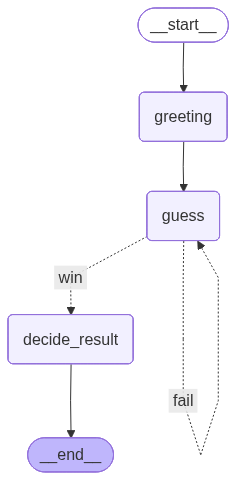

In [106]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [112]:
result = app.invoke({"number": 5, "max_attempts": 5})
#print(result)

... starting game
4
7
6
5
Game Result: WIN
